In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from flonacomldft.utils.io_utils import load_csv_file, load_pickle_file

In [4]:
isomers = torch.arange(0, 2)

train_zmats = [load_csv_file(
    "database/berendsen/converged/is{:d}_flow_train.csv".format(isomer)) 
    for isomer in isomers]
test_zmats = [load_csv_file(
    "database/berendsen/converged/is{:d}_flow_test.csv".format(isomer)) 
    for isomer in isomers]

In [5]:
isomers[0].item()

0

In [6]:
flow_ids = [20230520201411, 20230525163346] 
dict_flows_init = [load_pickle_file("database/berendsen/models/is{:d}_flow_dic_training_{:d}.pkl".format(isomer, flow_id)) for isomer, flow_id in zip(isomers, flow_ids)]

In [7]:
kb = 8.617333262e-5
T = 300
beta = 1 / (kb * T)
target_energy = lambda x: torch.tensor(-6.8+torch.rand(1)*0.5)


In [8]:
from flonacomldft.models.mixture import Mixture
from flonacomldft.internal_coordinates import join_data
from flonacomldft.sampling import run_metropolis
import copy

In [9]:
from flonacomldft.train_flow_from_data import train_flow

In [10]:
def Transpose(x):
    return x.permute(*torch.arange(x.ndim - 1, -1, -1))

In [11]:
def full_adaptative_sampling(
        flow_init_train,
        flow_init_test,
        init_mcmc,
        dict_flows_init,
        dict_mlps_init,
        flow_hyperparams,
        n_chains,
        n_steps,
        n_runs,
        dim=12,
        energy_type='mlp',
        mixture=False,
        T=300
        ):

    modes = torch.unique(flow_init_train[:, dim+1])

    xs_for_flows_train = [ flow_init_train[flow_init_train[:, dim+1] == mode] for mode in modes ]
    xs_for_flows_test = [ flow_init_test[flow_init_test[:, dim+1] == mode] for mode in modes ]

    dict_flows_training = [copy.deepcopy(dict_flows_init), ]

    flow_models = lambda dict_flows: [dict_flow['model'] for dict_flow in dict_flows]
    mlp_models = lambda dict_mlps: [dict_mlp['model'] for dict_mlp in dict_mlps]

    mcmc_runs = []

    xs = []
    us = []
    accs = []
    isomers = []
    
    init = init_mcmc

    #init = xs_for_flows_test[0][:n_chains]

    for i in range(n_runs):

        weights = torch.tensor([0.5, 0.5]).detach()
        mixture_model = Mixture(flow_models(dict_flows_training[i]), weights)

        mcmc_run = run_metropolis(
            model=mixture_model,
            init=init,
            n_chains=n_chains,
            n_steps=n_steps,
            id_run=i,
            energy_type=energy_type,
            mlp_models=mlp_models(dict_mlps_init),
            mixture=mixture,
            dim=dim,
            )
        
        mcmc_runs.append(mcmc_run)

        xs.append(mcmc_run["xs"])
        us.append(mcmc_run["us"])
        accs.append(mcmc_run["accs"])
        isomers.append(mcmc_run["isomers"])

        init = join_data(xs[i][-1].clone(), us[i][-1].clone(), isomers[i][-1].clone())

        #TODO: Chech size of xs_for_flows_train

        chains_flatten = Transpose(
            torch.cat(
                (
                    Transpose(xs[i].clone()),
                    Transpose(us[i].clone().reshape(n_steps, n_chains, 1)),
                    Transpose(isomers[i].clone().reshape(n_steps, n_chains, 1)),
                ),
                dim=0,
            )
        )

        chains_flatten = chains_flatten.reshape(n_steps * n_chains, chains_flatten.shape[-1])

        mask_flow = chains_flatten[:, -1]

        dict_new_flows = []

        for mode in modes.detach().numpy().astype(int):

            xs_from_chains = chains_flatten.clone()[mask_flow==mode].clone()

            # extend data set for flow training

            xs_for_flows_train[mode] = torch.cat(
                (xs_for_flows_train[mode].clone(), xs_from_chains.clone())
            )

            #add mlps
            dict_new_flow = train_flow(
                dict_flows_training[i][mode]['model'],
                xs_for_flows_train[mode],
                xs_for_flows_test[mode],
                #mlp_model=get_models(dict_mlps_training[-1])[0],
                **flow_hyperparams[mode],
                dim=dim
                )
            
            dict_new_flows.append(copy.deepcopy(dict_new_flow))
            
        else:
            dict_new_flow = copy.deepcopy(dict_flows_training[i][mode])
            dict_new_flows.append(dict_new_flow)

        dict_flows_training.append(dict_new_flows)

    to_return = {
        "dict_flows_training": dict_flows_training,
        "mcmc_runs": mcmc_runs,
        "xs": xs,
        "us": us,
        "accs": accs,
        "isomers": isomers,
    }

    return to_return

In [12]:
mlp_dic = {'model': target_energy}

In [13]:
flow_hyperparams = {'n_iter': 100,
    'lr': 1e-3,
    'use_scheduler': False,
    'step_schedule': 100,
    'save_splits': 10,
    'grad_clip': 1e4}


In [14]:
from flonacomldft.internal_coordinates import Coordinates_mapping
coord_mapping = Coordinates_mapping()

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

In [15]:
# To real centered data

train_xs = [coord_mapping.get_real_centered_from_internal(
                                    train_zmat[:, :12],
                                    train_zmat[:, 14],
                                    isomer=isomer.item(),
                                    energies=train_zmat[:, 12]
                                    ) for isomer, train_zmat in zip(isomers, train_zmats)]

train_xs = torch.stack(
                        [torch.cat( (
                                        x[0], x[2].reshape(-1, 1), 
                                        zmat_test[:, 13].reshape(-1, 1), 
                                        #x[1].reshape(-1, 1),
                                        ), 
                                        dim=1) 
                        for x, zmat_test in zip(train_xs, train_zmats)]
                    )
# Avoid using 15, add values or shape
train_xs = train_xs.clone().squeeze_().reshape(-1, train_xs.shape[-1]) 



In [16]:
test_xs = [coord_mapping.get_real_centered_from_internal(
                                        test_zmat[:, :12],
                                        test_zmat[:, 14],
                                        isomer=isomer.item(),
                                        energies=test_zmat[:, 12]
                                        ) for isomer, test_zmat in zip(isomers, test_zmats)]

test_xs = torch.stack(
                        [torch.cat((
                                        x[0], x[2].reshape(-1, 1),
                                        zmat_test[:, 13].reshape(-1, 1),
                                        #x[1].reshape(-1, 1),
                                        ),
                                        dim=1)
                                
                        for x, zmat_test in zip(test_xs, test_zmats)]
                )

test_xs = test_xs.clone().squeeze_().reshape(-1, test_xs.shape[-1])


In [17]:
n_runs = 3
n_chains = 5
n_steps = 10

shuffle = torch.randperm(test_xs.shape[0])
init_mcmc = test_xs[shuffle].clone()[:n_chains]

In [18]:
_ = full_adaptative_sampling(train_xs, 
                         test_xs,
                         init_mcmc, 
                         dim=12,
                         dict_flows_init=dict_flows_init,
                         dict_mlps_init=[mlp_dic, mlp_dic],
                         mixture=True,
                         flow_hyperparams=[flow_hyperparams, flow_hyperparams],
                         n_runs=n_runs,
                         n_chains=n_chains,
                         n_steps=n_steps,
                         energy_type='dft',
                        )

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

step: 0 	 acc: 0.20
t=0.0e+00 	 loss: -50.87	Gd: 1e+02	lr: 1.00e-03
t=1.0e+01 	 loss: 12.46	Gd: 1e+04	lr: 1.00e-03
t=2.0e+01 	 loss: -29.46	Gd: 5e+03	lr: 1.00e-03
t=3.0e+01 	 loss: -41.42	Gd: 3e+03	lr: 1.00e-03
t=4.0e+01 	 loss: -46.11	Gd: 2e+03	lr: 1.00e-03
t=5.0e+01 	 loss: -47.94	Gd: 1e+03	lr: 1.00e-03
t=6.0e+01 	 loss: -48.87	Gd: 3e+02	lr: 1.00e-03
t=7.0e+01 	 loss: -49.42	Gd: 3e+02	lr: 1.00e-03
t=8.0e+01 	 loss: -49.83	Gd: 2e+02	lr: 1.00e-03
t=9.0e+01 	 loss: -50.19	Gd: 1e+02	lr: 1.00e-03
t=0.0e+00 	 loss: -41.07	Gd: 7e-01	lr: 1.00e-03
t=1.0e+01 	 loss: -39.82	Gd: 1e+03	lr: 1.00e-03
t=2.0e+01 	 loss: -40.37	Gd: 4e+02	lr: 1.00e-03
t=3.0e+01 	 loss: -40.74	Gd: 3e+02	lr: 1.00e-03
t=4.0e+01 	 loss: -41.02	Gd: 2e+02	lr: 1.00e-03
t=5.0e+01 	 loss: -41.02	Gd: 1e+02	lr: 1.00e-03
t=6.0e+01 	 loss: -41.06	Gd: 6e+01	lr: 1.00e-03
t=7.0e+01 	 loss: -41.06	Gd: 5e+01	lr: 1.00e-03
t=8.0e+01 	 loss: -41.07	Gd: 2e+01	lr: 1.00e-03
t=9.0e+01 	 loss: -41.07	Gd: 9e+00	lr: 1.00e-03


/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

step: 0 	 acc: 0.00
t=0.0e+00 	 loss: -50.38	Gd: 5e+01	lr: 1.00e-03
t=1.0e+01 	 loss: -32.18	Gd: 4e+03	lr: 1.00e-03
t=2.0e+01 	 loss: -44.61	Gd: 2e+03	lr: 1.00e-03
t=3.0e+01 	 loss: -48.51	Gd: 7e+02	lr: 1.00e-03
t=4.0e+01 	 loss: -49.18	Gd: 6e+02	lr: 1.00e-03
t=5.0e+01 	 loss: -49.81	Gd: 4e+02	lr: 1.00e-03
t=6.0e+01 	 loss: -50.16	Gd: 4e+02	lr: 1.00e-03
t=7.0e+01 	 loss: -50.38	Gd: 2e+02	lr: 1.00e-03
t=8.0e+01 	 loss: -50.50	Gd: 4e+01	lr: 1.00e-03
t=9.0e+01 	 loss: -50.56	Gd: 1e+02	lr: 1.00e-03
t=0.0e+00 	 loss: -41.07	Gd: 1e+01	lr: 1.00e-03
t=1.0e+01 	 loss: -33.91	Gd: 2e+03	lr: 1.00e-03
t=2.0e+01 	 loss: -38.75	Gd: 1e+03	lr: 1.00e-03
t=3.0e+01 	 loss: -40.93	Gd: 3e+02	lr: 1.00e-03
t=4.0e+01 	 loss: -41.03	Gd: 1e+02	lr: 1.00e-03
t=5.0e+01 	 loss: -41.04	Gd: 1e+02	lr: 1.00e-03
t=6.0e+01 	 loss: -41.06	Gd: 5e+01	lr: 1.00e-03
t=7.0e+01 	 loss: -41.07	Gd: 2e+01	lr: 1.00e-03
t=8.0e+01 	 loss: -41.06	Gd: 6e+01	lr: 1.00e-03
t=9.0e+01 	 loss: -41.07	Gd: 5e+01	lr: 1.00e-03


/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

step: 0 	 acc: 0.00
t=0.0e+00 	 loss: -50.60	Gd: 2e+01	lr: 1.00e-03
t=1.0e+01 	 loss: -42.71	Gd: 2e+03	lr: 1.00e-03
t=2.0e+01 	 loss: -42.08	Gd: 2e+03	lr: 1.00e-03
t=3.0e+01 	 loss: -44.93	Gd: 2e+03	lr: 1.00e-03
t=4.0e+01 	 loss: -47.63	Gd: 1e+03	lr: 1.00e-03
t=5.0e+01 	 loss: -48.92	Gd: 8e+02	lr: 1.00e-03
t=6.0e+01 	 loss: -49.73	Gd: 4e+02	lr: 1.00e-03
t=7.0e+01 	 loss: -50.15	Gd: 3e+02	lr: 1.00e-03
t=8.0e+01 	 loss: -50.37	Gd: 1e+02	lr: 1.00e-03
t=9.0e+01 	 loss: -50.47	Gd: 5e+01	lr: 1.00e-03
t=0.0e+00 	 loss: -41.07	Gd: 7e+00	lr: 1.00e-03
t=1.0e+01 	 loss: -32.08	Gd: 3e+03	lr: 1.00e-03
t=2.0e+01 	 loss: -39.88	Gd: 1e+03	lr: 1.00e-03
t=3.0e+01 	 loss: -40.89	Gd: 3e+02	lr: 1.00e-03
t=4.0e+01 	 loss: -40.72	Gd: 5e+02	lr: 1.00e-03
t=5.0e+01 	 loss: -40.90	Gd: 4e+02	lr: 1.00e-03
t=6.0e+01 	 loss: -41.00	Gd: 2e+02	lr: 1.00e-03
t=7.0e+01 	 loss: -41.04	Gd: 1e+02	lr: 1.00e-03
t=8.0e+01 	 loss: -41.06	Gd: 7e+01	lr: 1.00e-03
t=9.0e+01 	 loss: -41.06	Gd: 1e+01	lr: 1.00e-03


In [19]:
chains_xs = torch.stack(_['xs']).reshape(-1, 12)
chains_us = torch.stack(_['us']).reshape(-1, 1)
chains_isomers = torch.stack(_['isomers']).reshape(-1, 1)

In [20]:
mcmc_xs = torch.cat([chains_xs, chains_us.reshape(-1, 1), chains_isomers.reshape(-1, 1)], dim=1)

In [21]:
mask = mcmc_xs[:, -1].squeeze()

In [22]:
mcmc_xs[mask==1].clone()

tensor([[-1.3928e-02,  2.1582e-02, -5.3950e-02,  ...,  4.8498e-03,
         -6.8032e+00,  1.0000e+00],
        [-2.5954e-02,  4.8642e-03, -1.0153e-01,  ..., -3.7147e-02,
         -6.8024e+00,  1.0000e+00],
        [ 2.4774e-03,  1.5397e-02,  5.2958e-02,  ..., -5.6028e-02,
         -6.6738e+00,  1.0000e+00],
        ...,
        [-1.4870e-02,  1.6065e-02, -1.0528e-01,  ...,  2.6140e-02,
         -6.6954e+00,  1.0000e+00],
        [-6.1921e-03,  7.2335e-03, -9.7462e-02,  ..., -2.5532e-02,
         -6.7934e+00,  1.0000e+00],
        [ 5.2545e-03, -3.1225e-03, -7.4551e-02,  ..., -1.7111e-02,
         -6.6984e+00,  1.0000e+00]], grad_fn=<CloneBackward0>)

In [23]:
mcmc_zmat = [coord_mapping.get_internal_from_real_centered(mcmc_xs[mcmc_xs[:, -1]==1][:, :12],
                                                          isomer=isomer.item(),
                                                          energies=mcmc_xs[mcmc_xs[:, -1]==1][:, 12],)
            for isomer in isomers]

mcmc_zmat

[(tensor([[ 2.7655,  2.7068,  2.7390,  ..., -0.0448, -0.1155, -3.1367],
          [ 2.7535,  2.6900,  2.6914,  ..., -0.0072, -0.1249, -3.1787],
          [ 2.7819,  2.7006,  2.8459,  ..., -0.0095,  0.0696, -3.1976],
          ...,
          [ 2.7645,  2.7012,  2.6877,  ..., -0.0718, -0.0928, -3.1155],
          [ 2.7732,  2.6924,  2.6955,  ..., -0.0036, -0.1054, -3.1671],
          [ 2.7847,  2.6820,  2.7184,  ..., -0.0253, -0.1035, -3.1587]],
         grad_fn=<AddBackward0>),
  tensor([-0.0165, -0.0195, -0.0089, -0.0165, -0.0195, -0.0089, -0.0165, -0.0111,
          -0.0087, -0.0089, -0.0165, -0.0364, -0.0087, -0.0089, -0.0165, -0.0079,
          -0.0087, -0.0089, -0.0165, -0.0079, -0.0087, -0.0089, -0.0291, -0.0079,
          -0.0021, -0.0089, -0.0291, -0.0079, -0.0021, -0.0089, -0.0291, -0.0079,
          -0.0021, -0.0089, -0.0291, -0.0079, -0.0021, -0.0263, -0.0291, -0.0079,
          -0.0021, -0.0263, -0.0291, -0.0079, -0.0021, -0.0263, -0.0291, -0.0079,
          -0.0021, -0.0263

<AxesSubplot:>

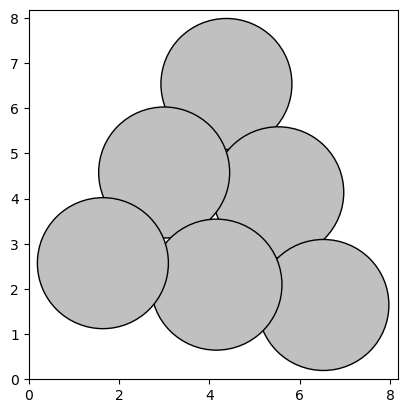

In [24]:
molecule = coord_mapping.build_molecule_from_zmat(mcmc_zmat[0][0][0])

from ase.visualize.plot import plot_atoms
plot_atoms(molecule)

In [25]:
from flonacomldft.collective_variables import get_CVs

In [26]:
cvs = get_CVs(mcmc_zmat[0][0])

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

In [27]:
from flonacomldft.utils.plots import Flonaco_Plotter

plotter = Flonaco_Plotter()

In [28]:
np.array(cvs).T[:, 0]

array([10.14453955, 10.48023617, 10.21383903, 10.14453955, 10.48023617,
       10.21383903, 10.14453955, 10.26217049, 10.35349421, 10.21383903,
       10.14453955, 10.26308621, 10.35349421, 10.21383903, 10.14453955,
       10.46134798, 10.35349421, 10.21383903, 10.14453955, 10.46134798,
       10.35349421, 10.21383903, 10.16104791, 10.46134798, 10.2996306 ,
       10.21383903, 10.16104791, 10.46134798, 10.2996306 , 10.21383903,
       10.16104791, 10.46134798, 10.2996306 , 10.21383903, 10.16104791,
       10.46134798, 10.2996306 , 10.18568585, 10.16104791, 10.46134798,
       10.2996306 , 10.18568585, 10.16104791, 10.46134798, 10.2996306 ,
       10.18568585, 10.16104791, 10.46134798, 10.2996306 , 10.18568585,
       10.16104791, 10.46134798, 10.2996306 , 10.18568585, 10.19750906,
       10.46134798, 10.2996306 , 10.18568585, 10.19750906, 10.46134798,
       10.2996306 , 10.18568585, 10.19750906, 10.46134798, 10.2996306 ,
       10.18568585, 10.19750906, 10.46134798, 10.2996306 , 10.18

<class 'list'>


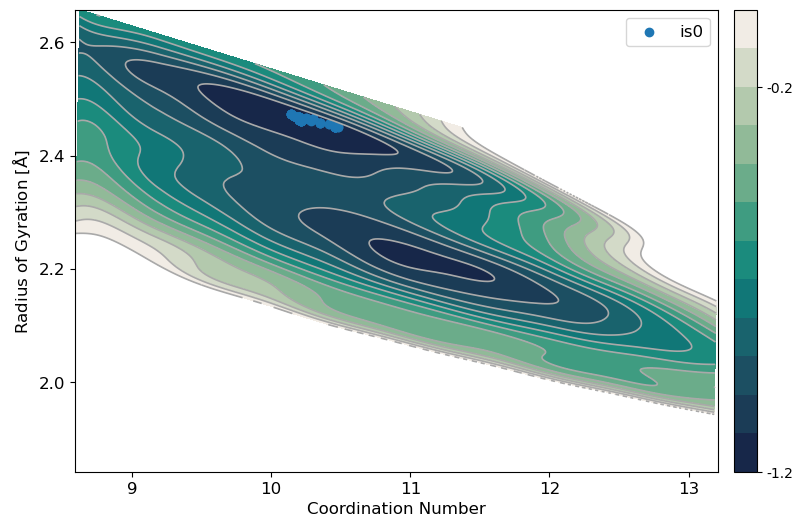

In [29]:
plotter.plot_collective_variables_on_fes(np.array(cvs).T, label='is0')